In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from RVUtils.Interpolation.GeneralCurveInterpolator import GeneralCurveInterpolator
from RVUtils.ust_viz import plot_usts, plot_usts_comparison
from RVUtils.plt_timeseries import make_secondary_axis_plot

import QuantLib as ql
from BT.misc import ql_cal_date_range

In [25]:
usts_mdp = FixedRateBondsMDP(source="USTS_WEBULL_WSJ_LIVE-RL")
usts_tb = FixedRateBondsTB(usts_mdp)

swaps_mdp = IRSwapsMDP(source="SDR_INTRADAY-RL_USD_SOFR_MT_MISC")
swaps_tb = IRSwapsTB(swaps_mdp)

In [26]:
start = NY_tz.localize(datetime.datetime(2025, 12, 19, 15, 00))
end = NY_tz.localize(datetime.datetime(2025, 12, 19, 15, 00))
ts_range = ql_cal_date_range(ql.UnitedStates(ql.UnitedStates.GovernmentBond), start=start, end=end, freq="1min") 
curves = swaps_mdp.get_data(request={"curve_name": "USD-SOFR-1D", "timestamp": start, "n_jobs": 15, "show_tqdm": True})

_N_SER_CONTRACTS:  11
_N_SFR_CONTRACTS:  12
_N_PLUS_FOMC_YRS:  1
_MT_TENORS:  ['5Y', '7Y', '10Y', '20Y', '30Y']
_MT_TENOR_MAX:  30Y
_EXTRAPOLATION_YRS:  30


CACHE HIT...: 100%|██████████| 1/1 [00:00<00:00, 42.13it/s]


SUCCESS: `conv_tol` reached after 10 iterations (levenberg_marquardt), `f_val`: 0.00040134569827957067, `time`: 0.2628s


(<Figure size 1600x900 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x25427ce7390>])

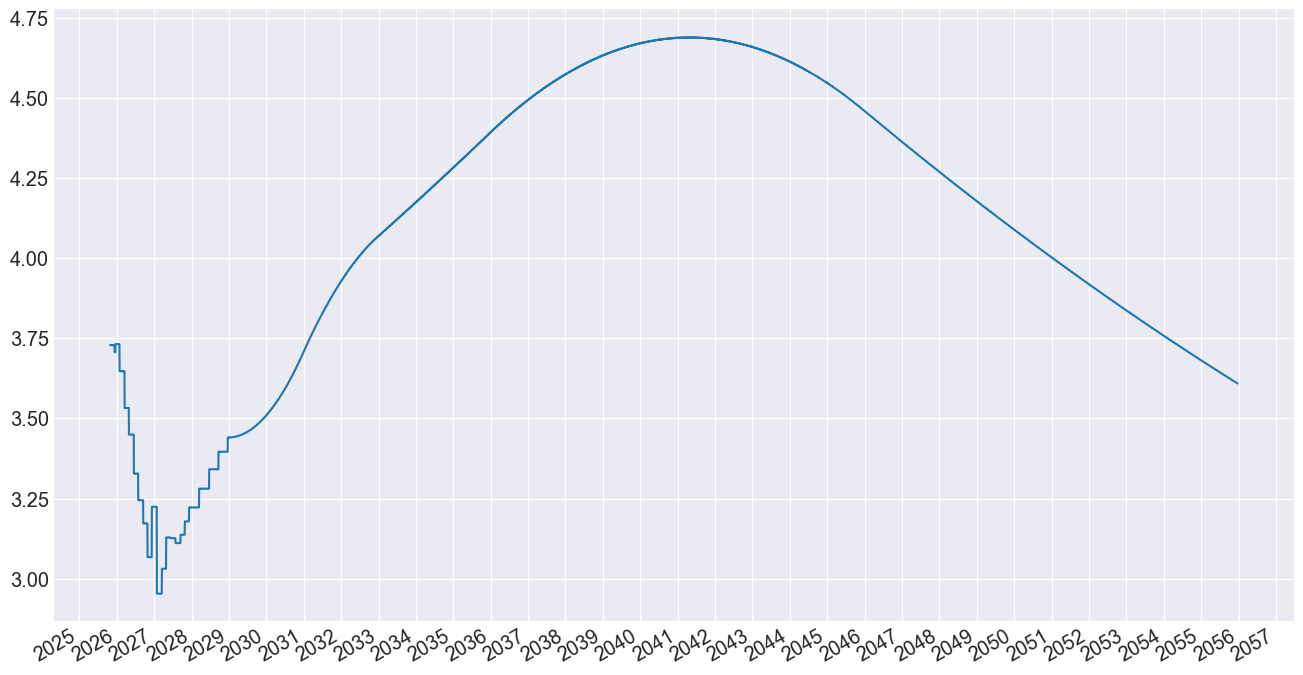

In [27]:
curves.handle().plot("1d")

In [ ]:
start = NY_tz.localize(datetime.datetime(2025, 12, 1, 6, 00))
end = NY_tz.localize(datetime.datetime(2025, 12, 19, 15, 00))
ts_range = ql_cal_date_range(ql.UnitedStates(ql.UnitedStates.GovernmentBond), start=start, end=end, freq="1min") 

# usts_df = usts_tb.get_timeseries(
#     start=None, end=None,
#     timestamps=ts_range,
#     queries=[
#         # FixedRateBondQuery(cusip="CT10/CT20/CT30"),
#         # FixedRateBondQuery(cusip="o10/o20/o30"),
#         # FixedRateBondQuery(cusip="oo10/oo20/oo30"),
#         # FixedRateBondQuery(cusip="oo20/o20"),
#         FixedRateBondQuery(cusip="CT5/CT30"),
#         # FixedRateBondQuery(cusip="1129-10/0530-10/0231-10"),
#         # FixedRateBondQuery(cusip="0530-10/0231-10"),
#     ],
# )

# usts_df

swaps_df = swaps_tb.get_timeseries(
    start=None,
    end=None,
    timestamps=ts_range,
    queries=[
        IRSwapQuery(curve="USD-SOFR-1D", tenor="dec25"),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10"),
    ],
    n_jobs=18,
)
swaps_df

In [5]:
# plot, fig, ax, ax2, legend = make_secondary_axis_plot(ylabel_left="RATE", ylabel_right="RATE", title=None, engine="plotly")
# plot(
#     df["o10/CT10 CURVE YTM"],
#     which="left",
#     indicators=[
        # {"kind": "last", "show_date": True, "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},
        # {"kind": "sma", "window": 20, "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "cum_change", "from_at": "2025-09-24", "label": "Chg from Logan TCGR Speech"},
        # {"kind": "hurst", "hide": True},
        # {"kind": "vol", "returns": "normal", "window": 20, "hide": True},
        # {"kind": "half_life", "method": "ou", "demean": True, "style": {"linestyle": ":"}, "hide": True},
    # ],
    # ou={"enable": True, "steps": 90, "add_metrics_to_legend": True}
# )
# legend(show_date=True)
# plt.show()

plot, fig, _, _, legend = make_secondary_axis_plot(engine="plotly")
# plot(usts_df["1129-10/0530-10/0231-10 FLY YTM"], which="left")
# plot(usts_df["CT5/CT30 CURVE YTM"], which="left")
plot(swaps_df["USD-SOFR-1D dec25 OUTRIGHT RATE"], which="left")
# plot(usts_df["o10/o20/o30 FLY YTM"], which="right")
# plot(usts_df["oo20/o20 CURVE YTM"], which="right")
legend(valfmt="{:.3f}", show_date=True)

In [ ]:
# 1129-10/0530-10/0231-10
# _alias_to_cusip(alias="0231-10", ref_table=usts_mdp.get_bond_reference_data(as_of_date=datetime.date.today()))

In [ ]:
from MDP.FixedRateBonds.WEBULL.WebullFintechFetcher import WebullFintechFetcher
from MDP.FixedRateBonds.WSJ.WSJFetcher import WSJFetcher

# start = CHI_tz.localize(datetime.datetime(2025, 10, 23, 7, 0))
# end = CHI_tz.localize(datetime.datetime(2025, 10, 24, 16, 00))

start = datetime.date(2025, 1, 1) 
end = datetime.date(2025, 10, 24)

wsjf = WSJFetcher()
ct_ts_df = wsjf.wsj_timeseries_api(
	wsj_ticker_keys=[
		# "TMUBMUSD01M",
		# "TMUBMUSD03M",
		# "TMUBMUSD04M",
		# "TMUBMUSD06M",
		"TMUBMUSD01Y",
		"TMUBMUSD02Y",
		"TMUBMUSD03Y",
		"TMUBMUSD05Y",
		"TMUBMUSD07Y",
		"TMUBMUSD10Y",
		"TMUBMUSD20Y",
		"TMUBMUSD30Y",
	],
	# start_date=start_date,
	# end_date=end_date,
	# intraday_timestamp=True,
	append_most_recent_last=True,
	one_df=True,
	show_tqdm=True,
)
ct_ts_df.columns = [
	# "1M",
	# "3M",
	# "4M",
	# "6M",
	"CT1",
	"CT2",
	"CT3",
	"CT5",
	"CT7",
	"CT10",
	"CT20",
	"CT30",
]

def merge_rows_same_date(df: pd.DataFrame) -> pd.DataFrame:
	if not isinstance(df.index, pd.DatetimeIndex):
		raise ValueError("The DataFrame index must be a DatetimeIndex.")

	grouped = df.groupby(df.index.normalize())

	merged_rows = []
	for _, group_df in grouped:
		group_df = group_df.sort_index()
		new_index = group_df.index.max()
		merged = group_df.iloc[-1].copy()
		for _, row in group_df.iloc[-2::-1].iterrows():
			merged = row.combine_first(merged)
		merged.name = new_index
		merged_rows.append(merged)

	merged_df = pd.DataFrame(merged_rows)
	merged_df.sort_index(inplace=True)
	return merged_df

ct_ts_df = merge_rows_same_date(ct_ts_df)

ct_ts_df: pd.DataFrame = ct_ts_df[
	(ct_ts_df.index.date >= start.date() if type(start) == datetime.datetime else ct_ts_df.index.date >= start)
	& (ct_ts_df.index.date <= end.date() if type(end) == datetime.datetime else ct_ts_df.index.date <= end)
]
ct_ts_df
ct_ts_df["2s10s"] = (ct_ts_df["CT10"] - ct_ts_df["CT2"]) * 100
ct_ts_df["2s7s"] = (ct_ts_df["CT7"] - ct_ts_df["CT2"]) * 100
ct_ts_df["5s30s"] = (ct_ts_df["CT30"] - ct_ts_df["CT5"]) * 100
ct_ts_df["2s5s10s"] = ((ct_ts_df["CT5"] - ct_ts_df["CT2"]) - (ct_ts_df["CT10"] - ct_ts_df["CT5"])) * 100 

ustf_df = WebullFintechFetcher(debug_verbose=True).eod_by_tickers(["TU", "FV", "TY", "UXY", "UB"], start=start, end=end, one_df=True)
ustf_df["TUL"] = 5 * ustf_df["TU"] - ustf_df["UXY"] 
ustf_df["TUT"] = 3 * ustf_df["TU"] - ustf_df["TY"]


ustf_df["TUF"] = 12 * ustf_df["TU"] - 10 * ustf_df["FV"]
ustf_df["FIX"] = 10 * ustf_df["FV"] - 5 * ustf_df["UXY"] 
ustf_df["TUF-FIX"] = ustf_df["TUF"] - ustf_df["FIX"] 

FETCHING FUTURES EOD...: 100%|██████████| 5/5 [00:00<00:00, 53.39it/s]


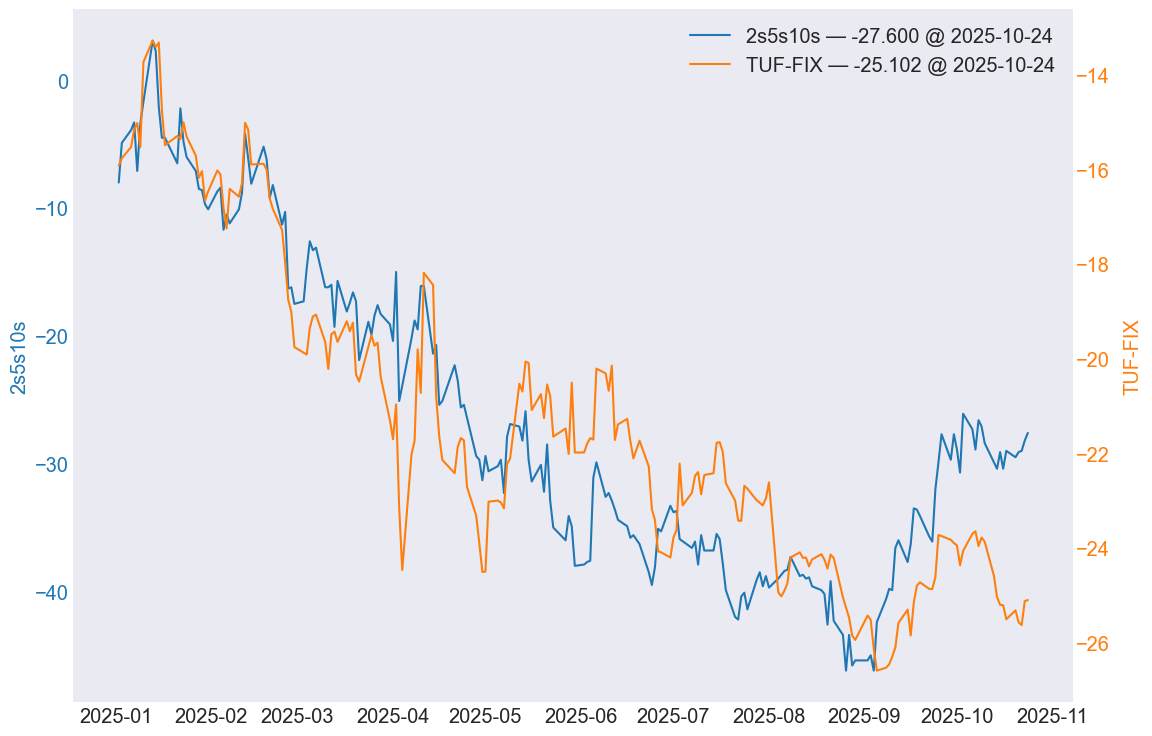

In [68]:
plot, fig, _, _, legend = make_secondary_axis_plot()
plot(ct_ts_df["2s5s10s"], which="left")
plot(ustf_df["TUF-FIX"], which="right")
# plot(ct_ts_df["2s7s"], which="left")
# plot(ustf_df["TUT"], which="right")
legend(valfmt="{:.3f}", show_date=True)

In [ ]:
swaps_tb = IRSwapsTB(mdp=IRSwapsMDP(source="SDR_INTRADAY_RL_USD_SOFR_MT_Q12"))


start = NY_tz.localize(datetime.datetime(2025, 8, 1, 7, 0))
end = NY_tz.localize(datetime.datetime(2025, 8, 1, 17, 0))
timestamps = pd.date_range(start, end, freq="1min")
df = swaps_tb.get_timeseries(queries=[IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", value=IRSwapValue.RATE)], timestamps=timestamps, start=None, end=None)
df

from RVUtils.plt_timeseries import make_secondary_axis_plot
plot, fig, ax, ax2, legend = make_secondary_axis_plot()
plot(
	df["USD-SOFR-1D 10Y OUTRIGHT RATE"],
    which="left",
)
legend(show_date=True)
plt.show()

In [10]:
from MDP.FixedRateBonds.WEBULL.WebullFintechFetcher import WebullFintechFetcher

codes = ["X5", "Z5", "F6", "G6", "H6", "J6", "K6"]
tickers = [f"SER{c}" for c in codes] + [f"FF{c}" for c in codes]

start = datetime.date(2025, 10, 1) 
end = datetime.date(2025, 11, 13)
df = WebullFintechFetcher(debug_verbose=True).eod_by_tickers(tickers, start=start, end=end)

# start = CHI_tz.localize(datetime.datetime(2025, 10, 27, 0, 0))
# end = CHI_tz.localize(datetime.datetime(2025, 11, 7, 16, 59))
# df = WebullFintechFetcher(debug_verbose=True).intraday_by_tickers(tickers, start=start, end=end)

for c in codes:
    df[f"SERFF{c}"] = df[f"SER{c}"] - df[f"FF{c}"]    
df["SERFFX5Z5"] = df["SERFFX5"] - df["SERFFZ5"] 
df["SERFFF6H6"] = df["SERFFF6"] - df["SERFFH6"] 

FETCHING FUTURES EOD...: 100%|██████████| 14/14 [00:00<00:00, 121.89it/s]


In [11]:
plot, fig, _, _, legend = make_secondary_axis_plot(engine="plotly")
# plot(usts_df["1129-10/0530-10/0231-10 FLY YTM"], which="left")
plot(df["SERFFF6H6"], which="left")
# plot(usts_df["o10/o20/o30 FLY YTM"], which="right")
# plot(usts_df["oo20/o20 CURVE YTM"], which="right")
legend(valfmt="{:.3f}", show_date=True)